## Imports

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import scipy.stats as stats
import numpy as np
import matplotlib.ticker as mticker
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


## Dataset: Active Licenses for Short-Term Residential Occupancy (STRO) — City of San Diego

SOURCE: https://data.sandiego.gov/datasets/stro-licenses/

This dataset contains all currently active licenses for Short-Term Residential Occupancy (STRO) issued by the City of San Diego, where hosts are legally required to obtain a license before renting a dwelling unit — or part of one — on a short-term basis. Each record represents a single licensed property, identified by a unique license ID and associated with a specific street address, neighborhood, and license tier. The tier system (1–4) captures meaningful variation in how intensively a unit is used for short-term rental: Tier 1 hosts rent infrequently (≤20 days/year), while Tiers 3 and 4 allow year-round commercial-style operation without an onsite residency requirement, with Tier 4 restricted exclusively to the Mission Beach Precise Planning Area. Because licenses are non-transferable and host-specific — with each host permitted to operate only one unit at a time — the dataset reflects the *active, regulated* supply of short-term rentals across San Diego's community planning areas at a given point in time. For our analysis of **mismatch hotspots**, this dataset serves as a critical signal of short-term rental pressure at the neighborhood level: a high concentration of Tier 3/4 licenses in a community planning area suggests that long-term housing units are being diverted toward short-term commercial use, potentially suppressing affordable housing supply in areas where it may already be constrained. Cross-referencing STRO license density and tier composition against affordability indicators will allow us to identify neighborhoods where housing pressure from short-term rentals compounds existing supply deficits.

---

### Column Descriptions

| Column | Description |
|---|---|
| `license_id` | Unique identifier for each STRO license (e.g., `STR-01553L`) |
| `address` | Full street address of the licensed dwelling unit |
| `street_number` | Numeric portion of the street address |
| `street_number_fraction` | Fractional component of the street number, if applicable |
| `street_direction` | Directional prefix of the street name (e.g., N, S, E, W) |
| `street_name` | Name of the street |
| `street_type` | Street suffix type (e.g., Dr, St, Ave) |
| `unit_type` | Type of unit designator (e.g., Apt, Suite), if applicable |
| `unit_number` | Unit or apartment number within a multi-unit building, if applicable |
| `city` | City name (San Diego) |
| `state` | State abbreviation (CA) |
| `zip` | ZIP code of the licensed property |
| `tier` | License tier (1–4), reflecting rental frequency, onsite host requirement, and geographic eligibility — see tier definitions below |
| `community_planning_area` | The official City of San Diego Community Planning Area in which the unit is located; serves as the primary neighborhood-level unit of analysis |
| `date_expiration` | Date on which the license expires |
| `rtax_no` | Rental Unit Business Tax account number associated with the license |
| `tot_no` | Transient Occupancy Tax (TOT) certificate number |
| `longitude` | Longitude coordinate of the licensed property |
| `latitude` | Latitude coordinate of the licensed property |
| `local_contact_contact_name` | Name of the designated local contact for the rental unit |
| `local_contact_phone` | Phone number of the local contact |
| `host_contact_name` | Name of the host (license holder) |
| `council_district` | San Diego City Council district in which the property is located |

---

### Tier Definitions

| Tier | Annual Rental Days | Host Must Reside Onsite ≥275 Days/Year | Eligible Areas |
|---|---|---|---|
| 1 | ≤ 20 days | No | All community planning areas |
| 2 | > 20 days | Yes | All community planning areas |
| 3 | ≥ 90 days | No | All areas *excluding* Mission Beach Precise Planning Area |
| 4 | ≥ 90 days | No | Mission Beach Precise Planning Area **only** |

## Preprocessing of the Active Licenses for Short-Term Occupancy Dataset

In [2]:
# ----------------------------------------------------------
# Initializing the Original Dataset
# ----------------------------------------------------------
stro_df = pd.read_csv('data/active_licenses_sht_.csv')
stro_df.head()

,license_id,address,street_number,street_number_fraction,street_direction,street_name,street_type,unit_type,unit_number,city,...,community_planning_area,date_expiration,rtax_no,tot_no,longitude,latitude,local_contact_contact_name,local_contact_phone,host_contact_name,council_district
0,STR-01553L,"4172 Caledonia Dr, San Diego, CA 92111",4172,NaN,NaN,Caledonia,Dr,NaN,NaN,San Diego,...,KEARNY MESA,2027-04-30,2014503891,630385,-117.157692,32.818308,Patrick Ponsaty,7.602708e+09,Patrick Ponsaty,6.0
1,STR-01603L,"10756 CORTE DE TIBURON, SAN DIEGO, CA 92130",10756,NaN,NaN,CORTE DE TIBURON,NaN,NaN,NaN,SAN DIEGO,...,TORREY HILLS,2027-04-30,2019501110,644026,-117.222058,32.912736,Benjamin Brown,8.589225e+09,Benjamin Brown,1.0
2,STR-01627L,"1838 32nd St, San Diego, CA 92102",1838,NaN,NaN,32nd,St,NaN,NaN,San Diego,...,GREATER GOLDEN HILL,2027-04-30,2017502004,624927,-117.125787,32.725076,Lori Miller,6.194718e+09,Stephen Miller,3.0
3,STR-01650L,"325 WEST St, SAN DIEGO, CA 92113",325,NaN,NaN,WEST,St,NaN,NaN,SAN DIEGO,...,SOUTHEASTERN SAN DIEGO,2027-04-30,2011804396,638038,-117.096621,32.701935,Patti Darensbourg,6.199713e+09,Patti Darensbourg,4.0
4,STR-01690L,"1731 PLUM St, #B, SAN DIEGO, CA 92106",1731,NaN,NaN,PLUM,St,NaN,B,SAN DIEGO,...,PENINSULA,2027-04-30,2020506600,624003,-117.229247,32.731320,vacasa vacasa,8.587804e+09,Tony Brake,2.0


In [3]:
# ----------------------------------------------------------
# Inspection of Shape, DTypes, Missing Values
# ----------------------------------------------------------
print("Shape:", stro_df.shape)
print("\nDtypes:\n", stro_df.dtypes)
print("\nMissing values (%):\n",
      (stro_df.isnull().mean() * 100).round(2).sort_values(ascending=False))

Shape: (8239, 23)

Dtypes:
 license_id                     object
address                        object
street_number                   int64
street_number_fraction         object
street_direction               object
street_name                    object
street_type                    object
unit_type                      object
unit_number                    object
city                           object
state                          object
zip                             int64
tier                           object
community_planning_area        object
date_expiration                object
rtax_no                         int64
tot_no                          int64
longitude                     float64
latitude                      float64
local_contact_contact_name     object
local_contact_phone           float64
host_contact_name              object
council_district              float64
dtype: object

Missing values (%):
 street_number_fraction        99.20
unit_type                 

In [4]:
# ----------------------------------------------------------
# Drop Columns with High Missingness or Low Analytical Value
# ----------------------------------------------------------
DROP_COLS = [
    'street_number_fraction',   # ~99% missing
    'street_direction',         # sparse, redundant with address
    'unit_type',                # mostly null; fine-grained address detail
]
stro_df.drop(columns=DROP_COLS, inplace=True, errors='ignore')
print("Remaining columns:", stro_df.columns.tolist())

Remaining columns: ['license_id', 'address', 'street_number', 'street_name', 'street_type', 'unit_number', 'city', 'state', 'zip', 'tier', 'community_planning_area', 'date_expiration', 'rtax_no', 'tot_no', 'longitude', 'latitude', 'local_contact_contact_name', 'local_contact_phone', 'host_contact_name', 'council_district']


In [5]:
# ----------------------------------------------------------
# Standardize String Columns
# ----------------------------------------------------------
STR_COLS = ['address', 'street_name', 'street_type',
            'city', 'state', 'community_planning_area',
            'local_contact_contact_name', 'host_contact_name']

for col in STR_COLS:
    if col in stro_df.columns:
        stro_df[col] = stro_df[col].str.strip().str.title()

stro_df['tier'] = stro_df['tier'].str.strip().str.title()

print("Unique tiers:", stro_df['tier'].unique())
print("Unique states:", stro_df['state'].unique())

Unique tiers: ['Tier 2' 'Tier 1' 'Tier 3' 'Tier 4']
Unique states: ['Ca']


In [6]:
# ----------------------------------------------------------
# Parse & Engineer Date Features
# ----------------------------------------------------------
stro_df['date_expiration'] = pd.to_datetime(stro_df['date_expiration'], errors='coerce')

today = pd.Timestamp.today().normalize()
stro_df['days_until_expiry'] = (stro_df['date_expiration'] - today).dt.days
stro_df['expiry_year']       = stro_df['date_expiration'].dt.year
stro_df['is_expiring_soon']  = stro_df['days_until_expiry'].between(0, 90)

print("Date parse failures:", stro_df['date_expiration'].isna().sum())
print("Licenses expiring within 90 days:", stro_df['is_expiring_soon'].sum())

Date parse failures: 0
Licenses expiring within 90 days: 290


In [7]:
# ----------------------------------------------------------
# Fix council_district dtype & Handle Nulls
# ----------------------------------------------------------
stro_df['council_district'] = (
    stro_df['council_district']
    .fillna(-1)
    .astype(int)
    .astype(str)
    .replace('-1', 'Unknown')
)

stro_df['unit_number'] = stro_df['unit_number'].fillna('').astype(str)

print("Null counts after cleaning:\n",
      stro_df.isnull().sum()[stro_df.isnull().sum() > 0])

Null counts after cleaning:
 street_type            325
longitude                1
latitude                 1
local_contact_phone      3
dtype: int64


In [8]:
# ----------------------------------------------------------
# Validate & Clean Coordinates
# ----------------------------------------------------------
LAT_MIN, LAT_MAX = 32.50, 33.20
LON_MIN, LON_MAX = -117.60, -116.90

coord_mask = (
    stro_df['latitude'].between(LAT_MIN, LAT_MAX) &
    stro_df['longitude'].between(LON_MIN, LON_MAX)
)
n_bad = (~coord_mask).sum()
print(f"Coordinates outside San Diego bbox: {n_bad} rows")
stro_df.loc[~coord_mask, ['latitude', 'longitude']] = np.nan

Coordinates outside San Diego bbox: 1 rows


In [9]:
# ----------------------------------------------------------
# Flag Proxy Hosts
# ----------------------------------------------------------
stro_df['is_proxy_managed'] = (
    stro_df['host_contact_name'].str.lower().str.strip() !=
    stro_df['local_contact_contact_name'].str.lower().str.strip()
)
print("Proxy-managed listings:", stro_df['is_proxy_managed'].sum(),
      f"({stro_df['is_proxy_managed'].mean():.1%})")

Proxy-managed listings: 4173 (50.6%)


In [10]:
# ----------------------------------------------------------
# Derive Tier Intensity Score
# ----------------------------------------------------------
TIER_INTENSITY = {'Tier 1': 1, 'Tier 2': 2, 'Tier 3': 3, 'Tier 4': 4}
stro_df['tier_intensity'] = stro_df['tier'].map(TIER_INTENSITY)

print("Tier intensity distribution:\n",
      stro_df['tier_intensity'].value_counts().sort_index())

Tier intensity distribution:
 tier_intensity
1     148
2    2347
3    4647
4    1097
Name: count, dtype: int64


In [23]:
# ----------------------------------------------------------
# Neighborhood-Level Aggregate Table
# ----------------------------------------------------------
nbhd = (
    stro_df
    .groupby('community_planning_area')
    .agg(
        total_licenses        = ('license_id',       'count'),
        tier1_count           = ('tier',             lambda x: (x == 'Tier 1').sum()),
        tier2_count           = ('tier',             lambda x: (x == 'Tier 2').sum()),
        tier3_count           = ('tier',             lambda x: (x == 'Tier 3').sum()),
        tier4_count           = ('tier',             lambda x: (x == 'Tier 4').sum()),
        pct_high_intensity    = ('tier_intensity',   lambda x: (x >= 3).mean()),
        pct_proxy_managed     = ('is_proxy_managed', 'mean'),
        avg_days_until_expiry = ('days_until_expiry','mean'),
        n_expiring_soon       = ('is_expiring_soon', 'sum'),
    )
    .reset_index()
    .sort_values('total_licenses', ascending=False)
)

print(f"Neighborhoods in dataset: {len(nbhd)}")
nbhd.head(10)

Neighborhoods in dataset: 50


,community_planning_area,total_licenses,tier1_count,tier2_count,tier3_count,tier4_count,pct_high_intensity,pct_proxy_managed,avg_days_until_expiry,n_expiring_soon
23,Mission Beach,1316,25,194,0,1097,0.833587,0.693769,426.636778,15
31,Pacific Beach,1167,15,219,933,0,0.799486,0.599829,415.895458,34
12,La Jolla,779,10,177,592,0,0.759949,0.662388,411.510911,36
48,Uptown,584,5,172,407,0,0.696918,0.465753,402.236301,21
27,Ocean Beach,566,3,91,472,0,0.833922,0.644876,418.058304,8
26,North Park,483,5,174,304,0,0.629400,0.383023,414.432712,15
4,Clairemont Mesa,449,11,203,235,0,0.523385,0.365256,417.527840,20
33,Peninsula,397,10,149,238,0,0.599496,0.440806,409.161209,21
8,Downtown,365,2,92,271,0,0.742466,0.520548,417.038356,19
42,Southeastern San Diego,250,4,68,178,0,0.712000,0.376000,405.528000,12


## Exploratory Data Analysis of Short-Term Occupancy

In [15]:
# setting graphs up
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

COLORS = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
TIER_ORDER = ['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4']

### City-Wide Tier Distributions

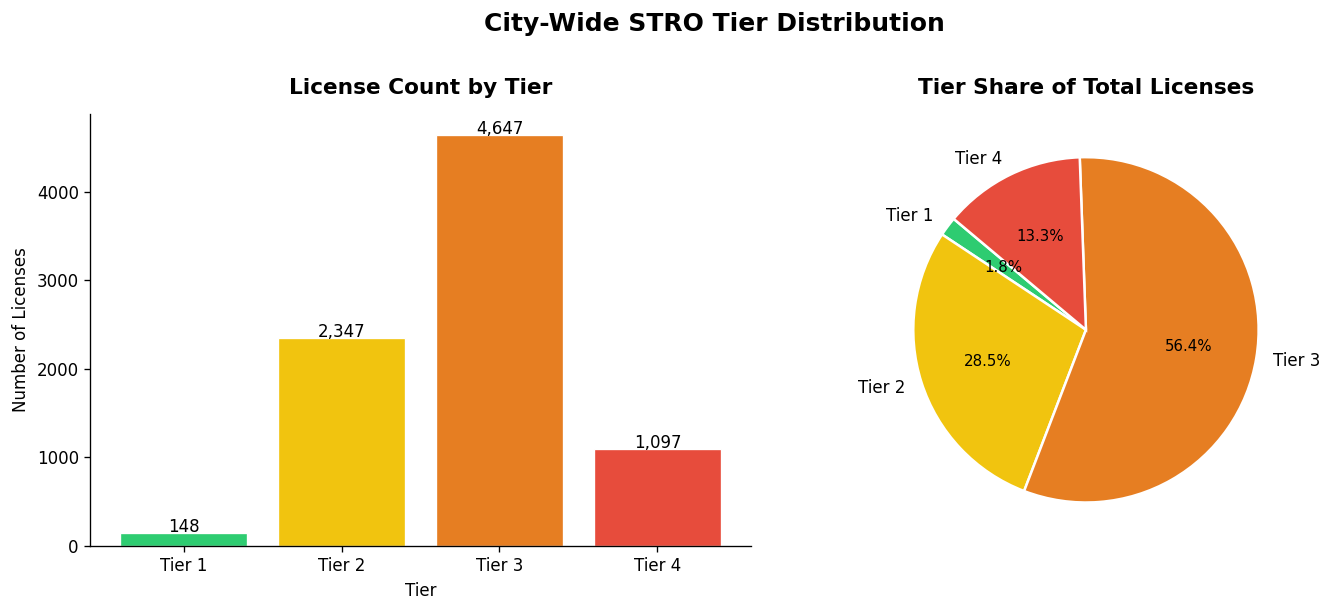

In [16]:
# ----------------------------------------------------------
# City-Wide Tier Distribution (Bar + Pie)
#       Baseline: what share of supply is high-intensity?
# ----------------------------------------------------------
tier_counts = stro_df['tier'].value_counts().reindex(TIER_ORDER).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar
axes[0].bar(tier_counts.index, tier_counts.values,
            color=COLORS, edgecolor='white', linewidth=0.8)
axes[0].set_title("License Count by Tier", fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel("Tier")
axes[0].set_ylabel("Number of Licenses")
for i, v in enumerate(tier_counts.values):
    axes[0].text(i, v + 8, f"{int(v):,}", ha='center', fontsize=10)

# Pie
wedges, texts, autotexts = axes[1].pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    colors=COLORS,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title("Tier Share of Total Licenses", fontsize=13, fontweight='bold', pad=12)

fig.suptitle("City-Wide STRO Tier Distribution", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Interpretation:
Tier 3 dominating at 4,647 licenses (nearly double Tier 2) tells you that the majority of San Diego's active STRO supply operates without any onsite residency requirement and at high annual rental frequency. This is not a city of occasional home-sharers — it is predominantly investor- or commercial-grade short-term rental activity. From a housing affordability standpoint, this means a large share of dwelling units have been effectively removed from the long-term rental or ownership market citywide.


### Top 20 Neighborhoods by License Count

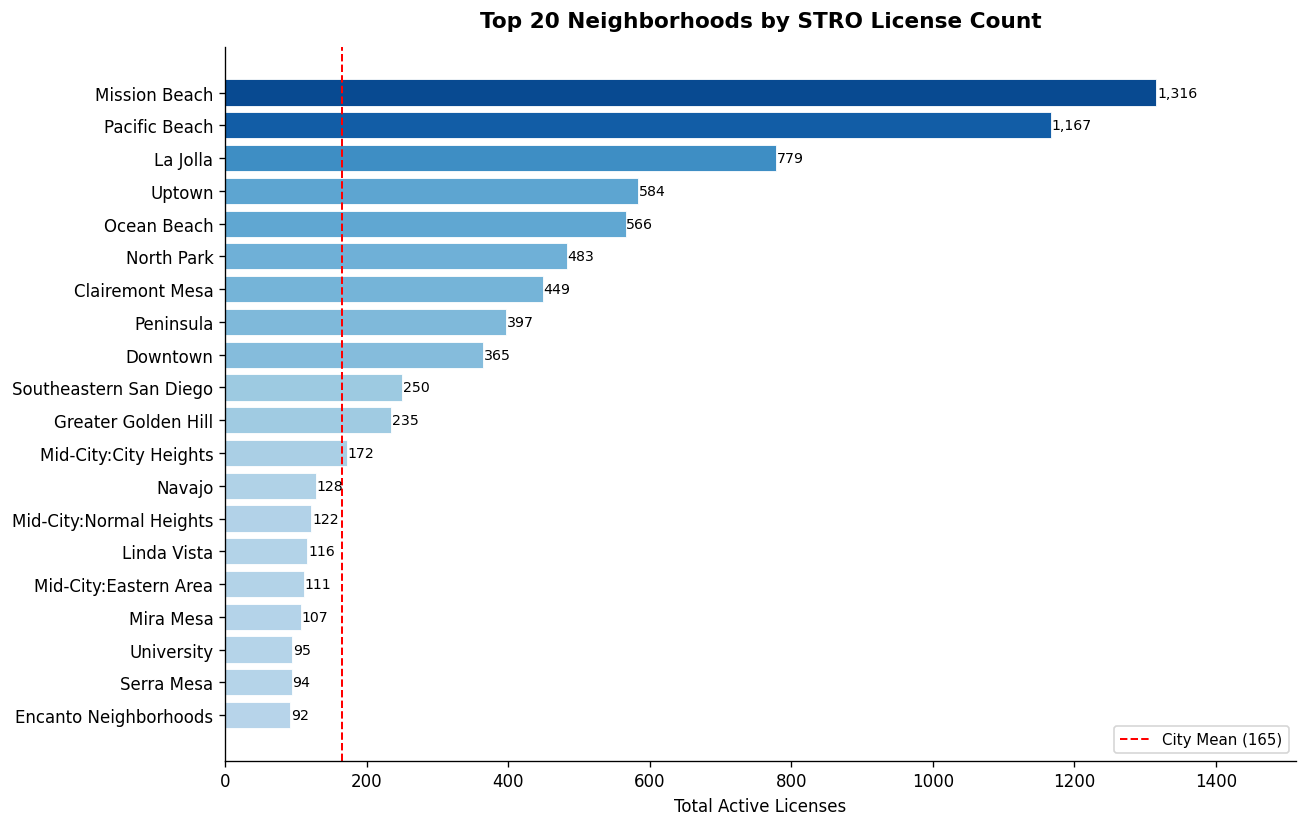

In [21]:
# ----------------------------------------------------------
# Top 20 Neighborhoods by License Count
#       Reveals where STRO activity is most spatially concentrated
# ----------------------------------------------------------
top20 = nbhd.nlargest(20, 'total_licenses').sort_values('total_licenses')
city_mean = nbhd['total_licenses'].mean()

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    top20['community_planning_area'],
    top20['total_licenses'],
    color=plt.cm.Blues(
        (top20['total_licenses'] - top20['total_licenses'].min()) /
        (top20['total_licenses'].max() - top20['total_licenses'].min()) * 0.6 + 0.3
    ),
    edgecolor='white', linewidth=0.5
)

ax.axvline(city_mean, color='red', linestyle='--', linewidth=1.2,
           label=f"City Mean ({city_mean:.0f})")

for bar, val in zip(bars, top20['total_licenses']):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va='center', fontsize=8.5)

ax.set_xlabel("Total Active Licenses")
ax.set_title("Top 20 Neighborhoods by STRO License Count",
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.set_xlim(0, top20['total_licenses'].max() * 1.15)
plt.tight_layout()
plt.show()

Interpretation:
These three neighborhoods aren't simply busy — they represent a qualitatively different kind of pressure. Mission Beach being almost entirely Tier 4 is significant because Tier 4 is geographically exclusive to that planning area by design, meaning the city's own regulatory framework acknowledges its unique commercial intensity. Pacific Beach and La Jolla combining high volume with dominant Tier 3 share means they face the same commercial pressure without even the geographic containment that Mission Beach has. For your mismatch analysis, these are your Tier 1 hotspot candidates — neighborhoods where housing units are being absorbed into the short-term rental market at scale.


### Stacked Tier Composition (Tier Based)

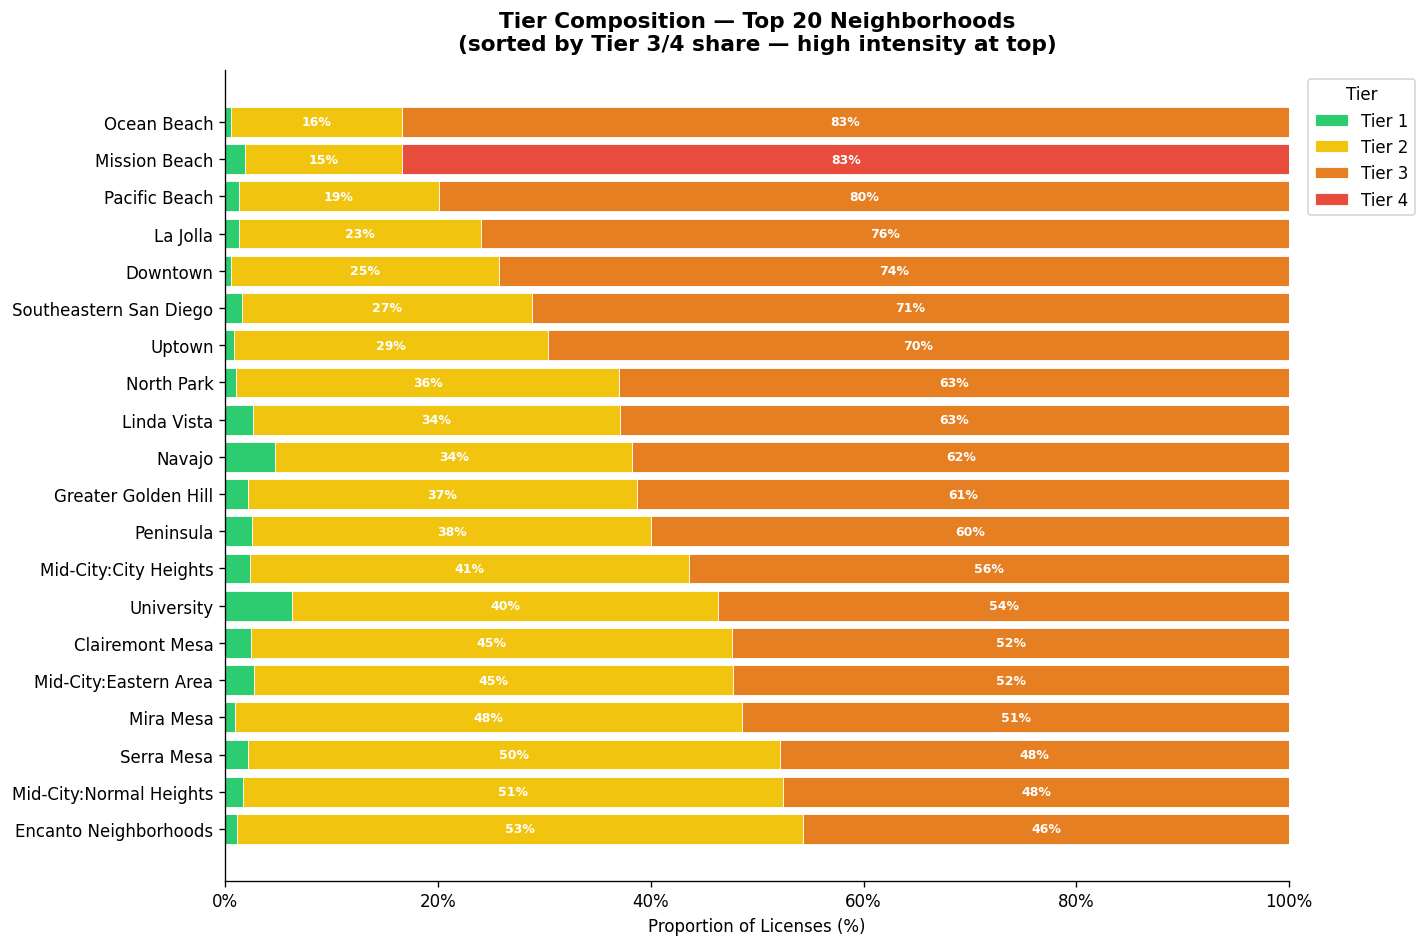

In [22]:
# ----------------------------------------------------------
# Stacked Tier Composition — Top 20 Neighborhoods
#       Core hotspot signal: which areas skew toward Tier 3/4?
# ----------------------------------------------------------
top20_names = nbhd.nlargest(20, 'total_licenses')['community_planning_area'].tolist()

tier_by_nbhd = (
    stro_df[stro_df['community_planning_area'].isin(top20_names)]
    .groupby(['community_planning_area', 'tier'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=TIER_ORDER, fill_value=0)
)
tier_pct = tier_by_nbhd.div(tier_by_nbhd.sum(axis=1), axis=0) * 100
tier_pct = (tier_pct
            .assign(_sort=tier_pct['Tier 3'] + tier_pct['Tier 4'])
            .sort_values('_sort')
            .drop(columns='_sort'))

fig, ax = plt.subplots(figsize=(12, 8))
left = np.zeros(len(tier_pct))

for tier, color in zip(TIER_ORDER, COLORS):
    vals = tier_pct[tier].values
    ax.barh(tier_pct.index, vals, left=left, color=color,
            label=tier, edgecolor='white', linewidth=0.5)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 8:
            ax.text(l + v / 2, i, f"{v:.0f}%", ha='center', va='center',
                    fontsize=7.5, color='white', fontweight='bold')
    left += vals

ax.set_xlabel("Proportion of Licenses (%)")
ax.set_title("Tier Composition — Top 20 Neighborhoods\n"
             "(sorted by Tier 3/4 share — high intensity at top)",
             fontsize=13, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title="Tier", bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

Interpretation: Ocean beach is THEE hotspot. 83% Tier 3 composition is the highest intensity ratio in the dataset, even though its absolute volume is lower than Mission Beach or Pacific Beach. This means nearly every STRO license in Ocean Beach is operating at commercial scale. When you layer in affordability data, Ocean Beach could emerge as a particularly acute mismatch hotspot — high intensity relative to its size, which may be quietly suppressing long-term supply without attracting the same attention as the larger beach communities.

The pattern of Tier 2 being more prominent in the lower-ranked neighborhoods (further down your stacked bar chart) is meaningful. Tier 2 requires the host to live onsite for at least 275 days per year, so a higher Tier 2 share indicates the neighborhood's STRO activity is still largely owner-occupied and supplementary rather than commercial. These areas face less displacement pressure from short-term rentals, and are less likely to be mismatch hotspots on the supply side — though they may still have affordability issues from other causes.


### Volume Vs. High Intensity Share Scatter

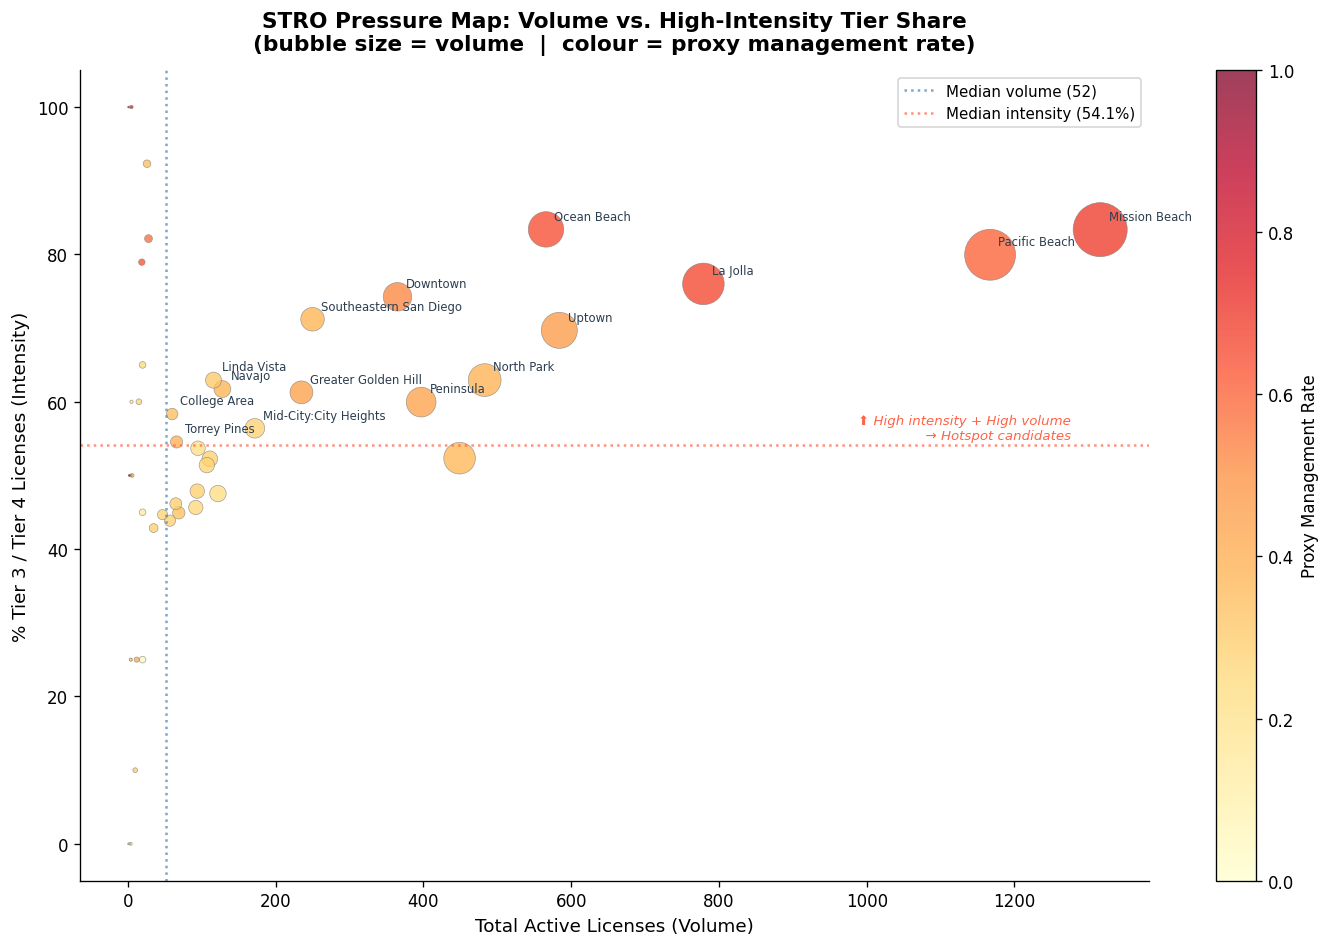

In [ ]:
# ----------------------------------------------------------
# Volume vs. High-Intensity Share Scatter
#       Quadrant map — top-right = prime mismatch hotspot candidates
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

sc = ax.scatter(
    nbhd['total_licenses'],
    nbhd['pct_high_intensity'] * 100,
    c=nbhd['pct_proxy_managed'],
    cmap='YlOrRd',
    s=nbhd['total_licenses'] * 0.8,
    alpha=0.75,
    edgecolors='grey',
    linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='Proxy Management Rate')

# Quadrant reference lines
med_vol = nbhd['total_licenses'].median()
med_int = nbhd['pct_high_intensity'].median() * 100
ax.axvline(med_vol, color='steelblue', linestyle=':', alpha=0.7,
           label=f'Median volume ({med_vol:.0f})')
ax.axhline(med_int, color='tomato', linestyle=':', alpha=0.7,
           label=f'Median intensity ({med_int:.1f}%)')

# Annotate top-right quadrant only (high volume AND high intensity)
hotspot_mask = (
    (nbhd['total_licenses'] > med_vol) &
    (nbhd['pct_high_intensity'] * 100 > med_int)
)
for _, row in nbhd[hotspot_mask].iterrows():
    ax.annotate(
        row['community_planning_area'],
        (row['total_licenses'], row['pct_high_intensity'] * 100),
        fontsize=7, ha='left', va='bottom',
        xytext=(5, 4), textcoords='offset points',
        color='#2c3e50'
    )

# Quadrant label
ax.text(nbhd['total_licenses'].max() * 0.97, med_int + 0.8,
        "⬆ High intensity + High volume\n  → Hotspot candidates",
        fontsize=8, color='tomato', ha='right', style='italic')

ax.set_xlabel("Total Active Licenses (Volume)", fontsize=11)
ax.set_ylabel("% Tier 3 / Tier 4 Licenses (Intensity)", fontsize=11)
ax.set_title("STRO Pressure Map: Volume vs. High-Intensity Tier Share\n"
             "(Bubble Size = Volume  |  Color = Proxy Management Rate)",
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Interpretation: The 13 neighborhoods below the median intensity line are your low-pressure baseline — relatively few licenses and low commercial intensity, suggesting STRO is not a significant force on housing supply there. The top-right quadrant — dominated by Mission Beach, Pacific Beach, and trailing closely by La Jolla and Ocean Beach — represents where both the volume and the commercial character of short-term rentals are highest simultaneously. These are the neighborhoods where, if your affordability data shows constrained supply or rising rents, you have the clearest evidence of a mismatch hotspot: STRO is actively competing with long-term residents for the same housing stock, at scale, with limited regulatory friction.

## Key Takeaway from this Dataset
The STRO dataset reveals that San Diego's short-term rental market is overwhelmingly commercial in character, with Tier 3 licenses — requiring no onsite residency — accounting for the majority of active supply and dominating nearly every high-volume neighborhood. This commercialisation is spatially concentrated along the coastal corridor, where Mission Beach, Pacific Beach, Ocean Beach, and La Jolla collectively combine high license volumes with high-intensity tier compositions, suggesting these neighborhoods have lost a disproportionate share of their long-term housing stock to short-term rental use. These coastal communities therefore represent the strongest candidates for mismatch hotspots, where STRO-driven supply pressure is most likely to compound existing affordability constraints — a hypothesis that can be tested once affordability indicators are joined to this neighborhood-level data.